<a href="https://colab.research.google.com/github/Whispering10/AfterWork/blob/main/%D0%9A%D1%83%D1%80%D1%81%D0%BE%D0%B2%D0%B0%D1%8F%20%D0%BF%D0%BE%20%D0%9D%D0%A1%D0%B2%D0%9E%D0%B8%D0%A2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
import joblib

In [2]:
from google.colab import files
uploaded = files.upload()
df = pd.read_excel(list(uploaded.keys())[0], sheet_name='1')

X = df[['TotalRunTime', 'AverageSpeed', 'AverageDash', 'StealthTime',
        'lIdleTime', 'AverageAttack', 'AverageParry', 'EnemiesKilled', 'ObjectsDestroyed']].values
y = df[['stealth', 'speedster', 'warrior']].values

Saving AllRuns_copy.xlsx to AllRuns_copy.xlsx


In [3]:
# Нормализация
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Разделение
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y.argmax(axis=1)
)

# Архитектура
model = tf.keras.Sequential([
    tf.keras.Input(shape=(9,)),
    tf.keras.layers.Dense(16, activation='relu',
                          kernel_regularizer=tf.keras.regularizers.l2(0.002)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(8, activation='relu',
                          kernel_regularizer=tf.keras.regularizers.l2(0.002)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(3, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8)              │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 419 (1.64 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 48 (192.00 B)

In [4]:
# Обучение
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    verbose=1,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            patience=30,
            restore_best_weights=True
        )
    ]
)

# Сохранение модели
model.save('player_style_classifier.h5')
joblib.dump(scaler, 'scaler.pkl')
print("Модель и скейлер сохранены.")

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 396ms/step - accuracy: 0.2627 - loss: 2.1181 - val_accuracy: 0.2000 - val_loss: 1.1739
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.2542 - loss: 2.0780 - val_accuracy: 0.2000 - val_loss: 1.1552
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2542 - loss: 2.0725 - val_accuracy: 0.2667 - val_loss: 1.1377
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3305 - loss: 1.5877 - val_accuracy: 0.3000 - val_loss: 1.1223
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3475 - loss: 1.6176 - val_accuracy: 0.3333 - val_loss: 1.1079
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2881 - loss: 1.7329 - val_accuracy: 0.4000 - val_loss: 1.0944
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4407 - loss: 1.4387 - val_accuracy: 0.4000 - val_loss: 1.0797
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3983 - loss: 1.3652 - val_accuracy: 0.4667 - val_loss

Модель и скейлер сохранены.



Точность на валидационной выборке: 0.9667
Потери на валидационной выборке: 0.2039
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step


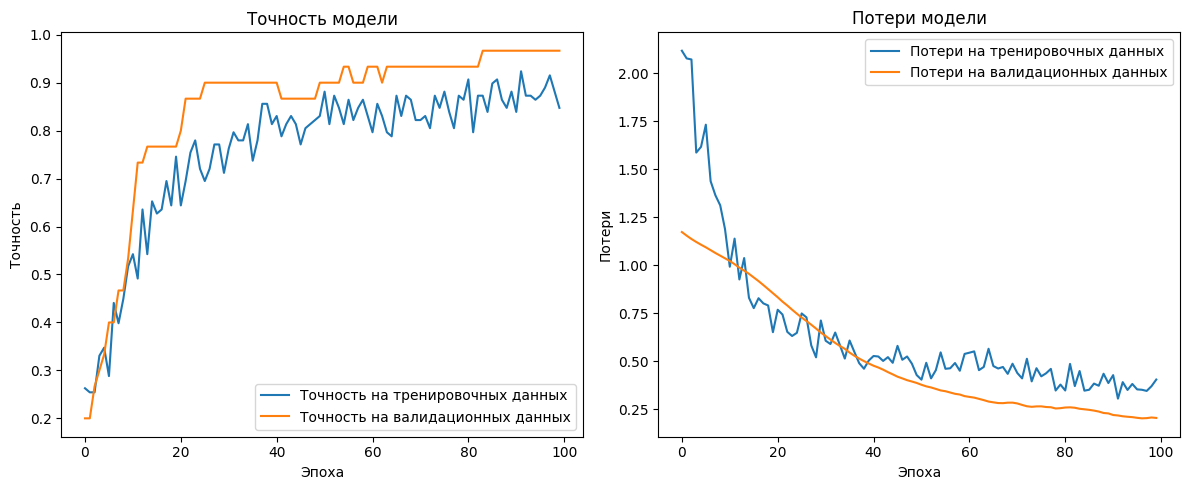

In [5]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

if 'model' in locals() and 'X_val' in locals() and X_val.shape[0] > 0:
    loss, accuracy = model.evaluate(X_val, y_val, verbose=0)
    print(f"\nТочность на валидационной выборке: {accuracy:.4f}")
    print(f"Потери на валидационной выборке: {loss:.4f}")

    y_pred_probs = model.predict(X_val)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_val, axis=1)

    class_names = ['Стелсер', 'Спидранер', 'Воин']
else:
    print("Модель или валидационные данные отсутствуют. Оценка не может быть выполнена.")

    # Визуализация истории обучения (точность и потери)
if 'history' in locals():
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Точность на тренировочных данных')
    plt.plot(history.history['val_accuracy'], label='Точность на валидационных данных')
    plt.title('Точность модели')
    plt.xlabel('Эпоха')
    plt.ylabel('Точность')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Потери на тренировочных данных')
    plt.plot(history.history['val_loss'], label='Потери на валидационных данных')
    plt.title('Потери модели')
    plt.xlabel('Эпоха')
    plt.ylabel('Потери')
    plt.legend()

    plt.tight_layout()
    plt.show()
else:
    print("История обучения отсутствует.")

In [6]:

def get_level_adjustments(pred_probs, base_traps=1.0, base_shelters=1.0, base_enemies=1.0, base_speed=1.0):
    """
    pred_probs — массив из 3 значений (softmax)
    Возвращает словарь с коэффициентами для генератора уровней Unity
    """
    pred_class = np.argmax(pred_probs)   # 0=воин, 1=спидранер, 2=стелсер

    trap_mult = base_traps          # ловушки
    shelter_mult = base_shelters    # укрытия
    enemy_mult = base_enemies       # враги
    speed_mult = base_speed         # скорость локации / экрана

    if pred_class == 1:   # СПИДРАНЕР
        trap_mult = 1.6     # увеличь число ловушек

    elif pred_class == 2:   # ВОИН
        enemy_mult = 0.65   # уменьши число врагов
        speed_mult = 1.35   # увеличь скорость локации

    elif pred_class == 0:   # СТЕЛСЕР
        shelter_mult = 0.65 # уменьши число укрытий
        enemy_mult = 1.45   # увеличь число врагов

    return {
        'trap_density_mult': round(trap_mult, 2),
        'shelter_density_mult': round(shelter_mult, 2),
        'enemy_density_mult': round(enemy_mult, 2),
        'location_speed_mult': round(speed_mult, 2),
        'predicted_class': ['Стелсер', 'Спидранер', 'Воин'][pred_class],
        'probabilities': [round(p, 4) for p in pred_probs]
    }

In [7]:

# Пробный вариант данных — три новых примера

test_samples = {
    "Тест 1 — Воин (ломает всё)": np.array([[28.19999, 3.608464, 0.24, 3.95838, 7.845332, 3.12032, 1.11968, 8.0, 3.0]]),
    "Тест 2 — Спидранер": np.array([[12.11986, 3.405562, 0.3, 0.2810746, 0.3689108, 0.2, 0.1, 0.0, 0.0]]),
    "Тест 3 — Стелсер (проходит тихо)": np.array([[21.47999, 4.276897, 0.3, 15.18525, 3.518595, 0.0, 0.0, 0.0, 0.0]])
}

for name, raw_features in test_samples.items():
    # Нормализация (точно как в обучении)
    scaled_features = scaler.transform(raw_features)

    # Предсказание
    probs = model.predict(scaled_features, verbose=0)[0]
    adjustments = get_level_adjustments(probs)

    print(f"\n{name}:")
    print(f"   Предсказанные вероятности: {adjustments['probabilities']}")
    print(f"   Определённый тип: {adjustments['predicted_class']}")
    print(f"   Корректировка уровня:")
    print(f"     • Плотность ловушек × {adjustments['trap_density_mult']}")
    print(f"     • Плотность укрытий × {adjustments['shelter_density_mult']}")
    print(f"     • Плотность врагов × {adjustments['enemy_density_mult']}")
    print(f"     • Скорость локации × {adjustments['location_speed_mult']}")


Тест 1 — Воин (ломает всё):
   Предсказанные вероятности: [np.float32(0.0217), np.float32(0.0084), np.float32(0.97)]
   Определённый тип: Воин
   Корректировка уровня:
     • Плотность ловушек × 1.0
     • Плотность укрытий × 1.0
     • Плотность врагов × 0.65
     • Скорость локации × 1.35

Тест 2 — Спидранер:
   Предсказанные вероятности: [np.float32(0.016), np.float32(0.9709), np.float32(0.0131)]
   Определённый тип: Спидранер
   Корректировка уровня:
     • Плотность ловушек × 1.6
     • Плотность укрытий × 1.0
     • Плотность врагов × 1.0
     • Скорость локации × 1.0

Тест 3 — Стелсер (проходит тихо):
   Предсказанные вероятности: [np.float32(0.9893), np.float32(0.0083), np.float32(0.0024)]
   Определённый тип: Стелсер
   Корректировка уровня:
     • Плотность ловушек × 1.0
     • Плотность укрытий × 0.65
     • Плотность врагов × 1.45
     • Скорость локации × 1.0
